# Segmentation Label Noise Benchmarking 

Let's load the "Experiments" Google Sheets file and analyze the results.

In [1]:
# load the data

import pandas as pd

sheet_id = "1AP_KH1cVSDwgpI1n7qK_VZU0Vi19Wh8vKo4jYWkuIXg"
gid = "0"  # use appropriate gid for the sheet tab (0 is usually the first)
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"


df = pd.read_csv(csv_url)
print(df.head())


    ID  Status    Job ID                                      Experiment ID  \
0  0.0     NaN  36497457                                                  -   
1  1.0     NaN  36520042  fold0_clients4_flrounds1000_localepochs1_20250...   
2  2.0     NaN  36520044  fold0_clients4_flrounds200_localepochs5_202502...   
3  3.0     NaN  36520051  fold0_clients4_flrounds100_localepochs10_20250...   
4  4.0     NaN  36520054  fold0_clients4_flrounds1000_localepochs1_20250...   

      Dataset/Clients       Dataset-Classes-Size-Noise/Consensus    Algo  \
0  033, 034, 035, 036  LIDC-Malignancy-Cropped-AnnotatorMajority  FedAvg   
1  033, 034, 035, 036  LIDC-Malignancy-Cropped-AnnotatorMajority  FedAvg   
2  033, 034, 035, 036  LIDC-Malignancy-Cropped-AnnotatorMajority  FedAvg   
3  033, 034, 035, 036  LIDC-Malignancy-Cropped-AnnotatorMajority  FedAvg   
4  037, 038, 039, 040   LIDC-Malignancy-Cropped-RandomMultiRater  FedAvg   

  Noise  Fold  #clients  ...  Comment      t [s]        t [d]     D_

**Research Question 1**

Comparison of FedAvg performance over different noise ratios, from clean to fully noise, over all datasets.
These experiments should demonstrate the problem that we and methods are trying to solve.

In [2]:
analyzed_experiments = {
    "FedAvg": {
        "LIDC_FedAvg_clean": [
            19,
            55,
            56
        ],
        "LIDC_FedAvg_roa50": [
            167,
            168,
            169
        ],
        "LIDC_FedAvg_roc50": [
            137,
            138,
            139
        ],
        "LIDC_FedAvg_noisy": [
            22,
            57,
            58
        ],
        #####################
        "RIGA_FedAvg_clean": [
            25,
            59,
            60
        ],
        "RIGA_FedAvg_roa50": [
            173,
            174,
            175
        ],
        "RIGA_FedAvg_roc66": [
            143,
            144,
            145
        ],
        "RIGA_FedAvg_noisy": [
            28,
            61,
            62
        ],
        #####################
        "Gleason_FedAvg_clean": [
            49,
            67,
            68
        ],
        "Gleason_FedAvg_roa50": [
            185,
            186,
            187
        ],
        "Gleason_FedAvg_roc66": [
            155,
            156,
            157
        ],
        "Gleason_FedAvg_noisy": [
            52,
            69,
            70
        ],
        #####################
        "MouseTumor_FedAvg_clean": [
            37,
            63,
            64
        ],
        "MouseTumor_FedAvg_roa50": [
            179,
            180,
            181
        ],
        "MouseTumor_FedAvg_roc60": [
            149,
            150,
            151
        ],
        "MouseTumor_FedAvg_noisy": [
            40,
            65,
            66
        ],
        #####################
        "MMIA_FedAvg_clean": [
            95,
            96,
            97
        ],
        "MMIA_FedAvg_roa50": [
            191,
            192,
            193
        ],
        "MMIA_FedAvg_roc50": [
            161,
            162,
            163
        ],
        "MMIA_FedAvg_noisy": [
            98,
            99,
            100
        ]
    },
    ##############################################
    "FedA3I": {
        "LIDC_FedA3I_clean": [
            71,
            72,
            73
        ],
        "LIDC_FedA3I_roa50": [
            170,
            171,
            172
        ],
        "LIDC_FedA3I_roc50": [
            140,
            141,
            142
        ],
        "LIDC_FedA3I_noisy": [
            74,
            75,
            76
        ],
        #####################
        "RIGA_FedA3I_clean": [
            77,
            78,
            79
        ],
        "RIGA_FedA3I_roa50": [
            176,
            177,
            178
        ],
        "RIGA_FedA3I_roc66": [
            146,
            147,
            148
        ],
        "RIGA_FedA3I_noisy": [
            80,
            81,
            82
        ],
        #####################
        "Gleason_FedA3I_clean": [
            89,
            90,
            91
        ],
        "Gleason_FedA3I_roa50": [
            188,
            189,
            190
        ],
        "Gleason_FedA3I_roc66": [
            158,
            159,
            160
        ],
        "Gleason_FedA3I_noisy": [
            92,
            93,
            94
        ],
        #####################
        "MouseTumor_FedA3I_clean": [
            83,
            84,
            85
        ],
        "MouseTumor_FedA3I_roa50": [
            182,
            183,
            184
        ],
        "MouseTumor_FedA3I_roc60": [
            152,
            153,
            154
        ],
        "MouseTumor_FedA3I_noisy": [
            86,
            87,
            88
        ],
        #####################
        "MMIA_FedA3I_clean": [
            101,
            102,
            103
        ],
        "MMIA_FedA3I_roa50": [
            194,
            195,
            196
        ],
        "MMIA_FedA3I_roc50": [
            164,
            165,
            166
        ],
        "MMIA_FedA3I_noisy": [
            104,
            105,
            106
        ]
    }
    ##############################################
}
    

Filter from experiments dataframe only the analyzed_experiments:

In [3]:
# Flatten the dictionary into a list of (group_name, index) tuples
filtered_rows = []
group_labels = []

for group, indices in analyzed_experiments["FedAvg"].items():
    for idx in indices:
        filtered_rows.append(idx)
        group_labels.append(group)

# Create the filtered DataFrame in the exact order
filtered_df = df.loc[filtered_rows].copy()
filtered_df["Group"] = group_labels  # add group info as a new column

# Reset index for cleanliness (optional)
filtered_df.reset_index(drop=True, inplace=True)

# Show result
filtered_df.head()

,ID,Status,Job ID,Experiment ID,Dataset/Clients,Dataset-Classes-Size-Noise/Consensus,Algo,Noise,Fold,#clients,...,t [s],t [d],D_val(c0),D_val(c1),D_val(c2),D_val(c3),D_val(c4),Mean(D_val),Std(D_val),Group
0,19.0,NaN,37565764,fold0_clients4_flrounds250_localepochs1_202503...,"041, 042, 043, 044",LIDC-Cropped-AnnotatorMajority,FedAvg,0,0.0,4.0,...,269443.0,"3,118553241","0,5917215378","0,5440127224","0,6253631756","0,7659629892",NaN,"0,6317651062","0,09548826235",LIDC_FedAvg_clean
1,55.0,NaN,38003824,fold1_clients4_flrounds250_localepochs1_202504...,"041, 042, 043, 044",LIDC-Cropped-AnnotatorMajority,FedAvg,0,1.0,4.0,...,NaN,NaN,"0,5924102834","0,6564106768","0,5514244864","0,511360507",NaN,"0,5779014884","0,06192180992",LIDC_FedAvg_clean
2,56.0,NaN,38003833,fold2_clients4_flrounds250_localepochs1_202504...,"041, 042, 043, 044",LIDC-Cropped-AnnotatorMajority,FedAvg,0,2.0,4.0,...,NaN,NaN,"0,5897942699","0,5239341894","0,6232886532","0,4700927382",NaN,"0,5517774627","0,06832952043",LIDC_FedAvg_clean
3,167.0,NaN,"38778088, 38866047",fedavg_noiseroa0.5_fold0_clients4_flrounds250_...,"041(045), 042(046), 043(047), 044(048)",LIDC-Cropped-AnnotatorMajority/RandomMultiRater,FedAvg,r.o.a(50),0.0,4.0,...,NaN,NaN,"0,5808802146","0,553486132","0,6316992444","0,6186251792",NaN,"0,5961726925","0,035694315",LIDC_FedAvg_roa50
4,168.0,NaN,"39114492, 39264373",fedavg_noiseroa0.5_fold1_clients4_flrounds250_...,"041(045), 042(046), 043(047), 044(048)",LIDC-Cropped-AnnotatorMajority/RandomMultiRater,FedAvg,r.o.a(50),1.0,4.0,...,NaN,NaN,"0,5956045017","0,6414891936","0,5509527968","0,5209980642",NaN,"0,5772611391","0,05266049882",LIDC_FedAvg_roa50


Let's compute the average Dice score over the 3 folds per experiment:

In [4]:
# Step 1: Convert Mean(D_val) to float (replace ',' with '.' and cast)
filtered_df["Mean(D_val)_float"] = (
    filtered_df["Mean(D_val)"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Step 2: Compute the average per group
group_means = (
    filtered_df
    .groupby("Group")["Mean(D_val)_float"]
    .mean()
    .rename("avg_mean_Dval")
)

# Step 3: Map back to each row
filtered_df["avg_mean_Dval"] = filtered_df["Group"].map(group_means)

# Optional: round for readability
filtered_df["avg_mean_Dval"] = filtered_df["avg_mean_Dval"].round(4)

# Result
filtered_df.head()


,ID,Status,Job ID,Experiment ID,Dataset/Clients,Dataset-Classes-Size-Noise/Consensus,Algo,Noise,Fold,#clients,...,D_val(c0),D_val(c1),D_val(c2),D_val(c3),D_val(c4),Mean(D_val),Std(D_val),Group,Mean(D_val)_float,avg_mean_Dval
0,19.0,NaN,37565764,fold0_clients4_flrounds250_localepochs1_202503...,"041, 042, 043, 044",LIDC-Cropped-AnnotatorMajority,FedAvg,0,0.0,4.0,...,"0,5917215378","0,5440127224","0,6253631756","0,7659629892",NaN,"0,6317651062","0,09548826235",LIDC_FedAvg_clean,0.631765,0.5871
1,55.0,NaN,38003824,fold1_clients4_flrounds250_localepochs1_202504...,"041, 042, 043, 044",LIDC-Cropped-AnnotatorMajority,FedAvg,0,1.0,4.0,...,"0,5924102834","0,6564106768","0,5514244864","0,511360507",NaN,"0,5779014884","0,06192180992",LIDC_FedAvg_clean,0.577901,0.5871
2,56.0,NaN,38003833,fold2_clients4_flrounds250_localepochs1_202504...,"041, 042, 043, 044",LIDC-Cropped-AnnotatorMajority,FedAvg,0,2.0,4.0,...,"0,5897942699","0,5239341894","0,6232886532","0,4700927382",NaN,"0,5517774627","0,06832952043",LIDC_FedAvg_clean,0.551777,0.5871
3,167.0,NaN,"38778088, 38866047",fedavg_noiseroa0.5_fold0_clients4_flrounds250_...,"041(045), 042(046), 043(047), 044(048)",LIDC-Cropped-AnnotatorMajority/RandomMultiRater,FedAvg,r.o.a(50),0.0,4.0,...,"0,5808802146","0,553486132","0,6316992444","0,6186251792",NaN,"0,5961726925","0,035694315",LIDC_FedAvg_roa50,0.596173,0.5772
4,168.0,NaN,"39114492, 39264373",fedavg_noiseroa0.5_fold1_clients4_flrounds250_...,"041(045), 042(046), 043(047), 044(048)",LIDC-Cropped-AnnotatorMajority/RandomMultiRater,FedAvg,r.o.a(50),1.0,4.0,...,"0,5956045017","0,6414891936","0,5509527968","0,5209980642",NaN,"0,5772611391","0,05266049882",LIDC_FedAvg_roa50,0.577261,0.5772


Let's plot the results!

In [5]:
!pip install matplotlib seaborn

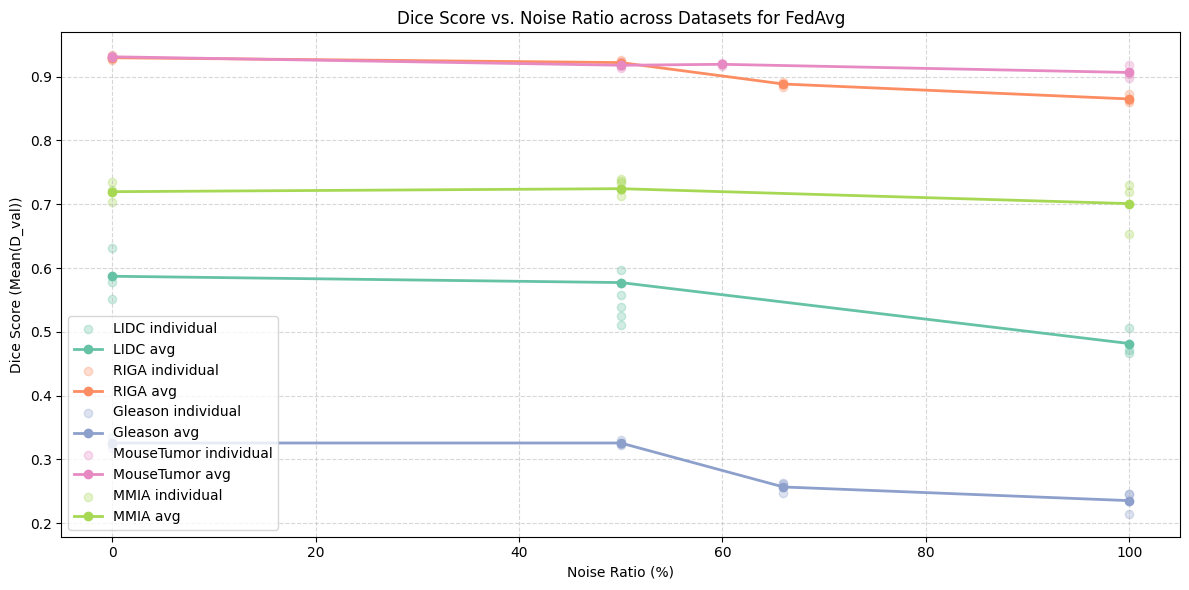

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Step 1: Create a new column for the numeric noise ratio ---
def extract_noise_ratio(group_name):
    # Check for a number like 'roa50', 'roc66', etc.
    match = re.search(r'(ro[ac])(\d+)', group_name)
    if match:
        return int(match.group(2))
    elif "clean" in group_name:
        return 0
    elif "noisy" in group_name:
        return 100
    else:
        return None  # or np.nan

filtered_df["NoiseRatio"] = filtered_df["Group"].apply(extract_noise_ratio)

# --- Step 2: Convert Mean(D_val) to float if not already ---
if "Mean(D_val)_float" not in filtered_df.columns:
    filtered_df["Mean(D_val)_float"] = (
        filtered_df["Mean(D_val)"]
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

# --- Step 3: Plot ---
plt.figure(figsize=(12, 6))

# Use a color palette per dataset
palette = sns.color_palette("Set2", n_colors=5)

# Extract datasets (e.g. LIDC, RIGA...) from group names
filtered_df["Dataset"] = filtered_df["Group"].apply(lambda g: g.split("_")[0])

# Plot per dataset
for i, dataset in enumerate(filtered_df["Dataset"].unique()):
    df_subset = filtered_df[filtered_df["Dataset"] == dataset]
    
    # Plot individual runs (low alpha for transparency)
    plt.scatter(
        df_subset["NoiseRatio"],
        df_subset["Mean(D_val)_float"],
        color=palette[i],
        alpha=0.3,
        label=f"{dataset} individual"
    )
    
    # Plot group average (bold points)
    group_avg = (
        df_subset.groupby("NoiseRatio")["avg_mean_Dval"].first().reset_index()
    )
    plt.plot(
        group_avg["NoiseRatio"],
        group_avg["avg_mean_Dval"],
        color=palette[i],
        marker='o',
        linewidth=2,
        label=f"{dataset} avg"
    )

# --- Final plot formatting ---
plt.xlabel("Noise Ratio (%)")
plt.ylabel("Dice Score (Mean(D_val))")
plt.title("Dice Score vs. Noise Ratio across Datasets for FedAvg")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("dice_vs_noise.png", dpi=300)
plt.show()


Let's plot this trend also for FedA3I.

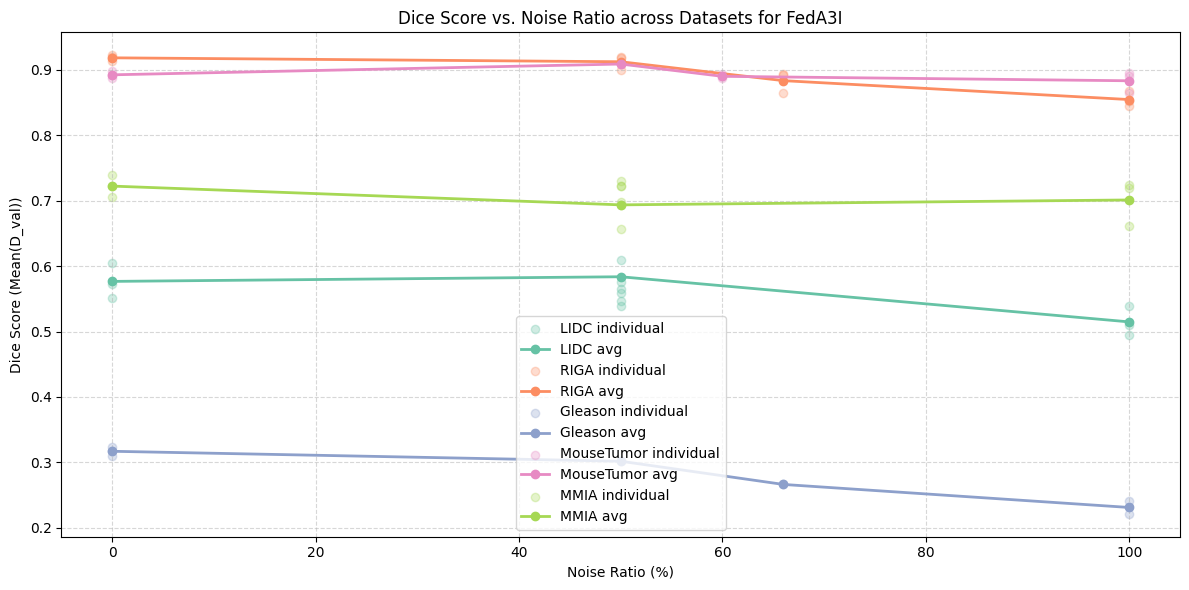

In [7]:
# repeating all of this code is very ugly, but sufficient for this purpose now :D 

# Flatten the dictionary into a list of (group_name, index) tuples
filtered_rows = []
group_labels = []

for group, indices in analyzed_experiments["FedA3I"].items():
    for idx in indices:
        filtered_rows.append(idx)
        group_labels.append(group)

# Create the filtered DataFrame in the exact order
filtered_df = df.loc[filtered_rows].copy()
filtered_df["Group"] = group_labels  # add group info as a new column

# Reset index for cleanliness (optional)
filtered_df.reset_index(drop=True, inplace=True)

# Show result
filtered_df.head()


# Step 1: Convert Mean(D_val) to float (replace ',' with '.' and cast)
filtered_df["Mean(D_val)_float"] = (
    filtered_df["Mean(D_val)"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Step 2: Compute the average per group
group_means = (
    filtered_df
    .groupby("Group")["Mean(D_val)_float"]
    .mean()
    .rename("avg_mean_Dval")
)

# Step 3: Map back to each row
filtered_df["avg_mean_Dval"] = filtered_df["Group"].map(group_means)

# Optional: round for readability
filtered_df["avg_mean_Dval"] = filtered_df["avg_mean_Dval"].round(4)

# Result
filtered_df.head()


import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Step 1: Create a new column for the numeric noise ratio ---
def extract_noise_ratio(group_name):
    # Check for a number like 'roa50', 'roc66', etc.
    match = re.search(r'(ro[ac])(\d+)', group_name)
    if match:
        return int(match.group(2))
    elif "clean" in group_name:
        return 0
    elif "noisy" in group_name:
        return 100
    else:
        return None  # or np.nan

filtered_df["NoiseRatio"] = filtered_df["Group"].apply(extract_noise_ratio)

# --- Step 2: Convert Mean(D_val) to float if not already ---
if "Mean(D_val)_float" not in filtered_df.columns:
    filtered_df["Mean(D_val)_float"] = (
        filtered_df["Mean(D_val)"]
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

# --- Step 3: Plot ---
plt.figure(figsize=(12, 6))

# Use a color palette per dataset
palette = sns.color_palette("Set2", n_colors=5)

# Extract datasets (e.g. LIDC, RIGA...) from group names
filtered_df["Dataset"] = filtered_df["Group"].apply(lambda g: g.split("_")[0])

# Plot per dataset
for i, dataset in enumerate(filtered_df["Dataset"].unique()):
    df_subset = filtered_df[filtered_df["Dataset"] == dataset]
    
    # Plot individual runs (low alpha for transparency)
    plt.scatter(
        df_subset["NoiseRatio"],
        df_subset["Mean(D_val)_float"],
        color=palette[i],
        alpha=0.3,
        label=f"{dataset} individual"
    )
    
    # Plot group average (bold points)
    group_avg = (
        df_subset.groupby("NoiseRatio")["avg_mean_Dval"].first().reset_index()
    )
    plt.plot(
        group_avg["NoiseRatio"],
        group_avg["avg_mean_Dval"],
        color=palette[i],
        marker='o',
        linewidth=2,
        label=f"{dataset} avg"
    )

# --- Final plot formatting ---
plt.xlabel("Noise Ratio (%)")
plt.ylabel("Dice Score (Mean(D_val))")
plt.title("Dice Score vs. Noise Ratio across Datasets for FedA3I")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("dice_vs_noise.png", dpi=300)
plt.show()
